# Results Analysis

This notebook analyzes the hyperparameter sweep results.

In [2]:
import sys
from pathlib import Path

# Ensure the src directory is in the path to import plot_utils
sys.path.append(str(Path("..").resolve()))

from plot_utils import *

## Faster R-CNN

### 1. Freeze Layers Sweep

Loaded 12 runs for the Freeze sweep.


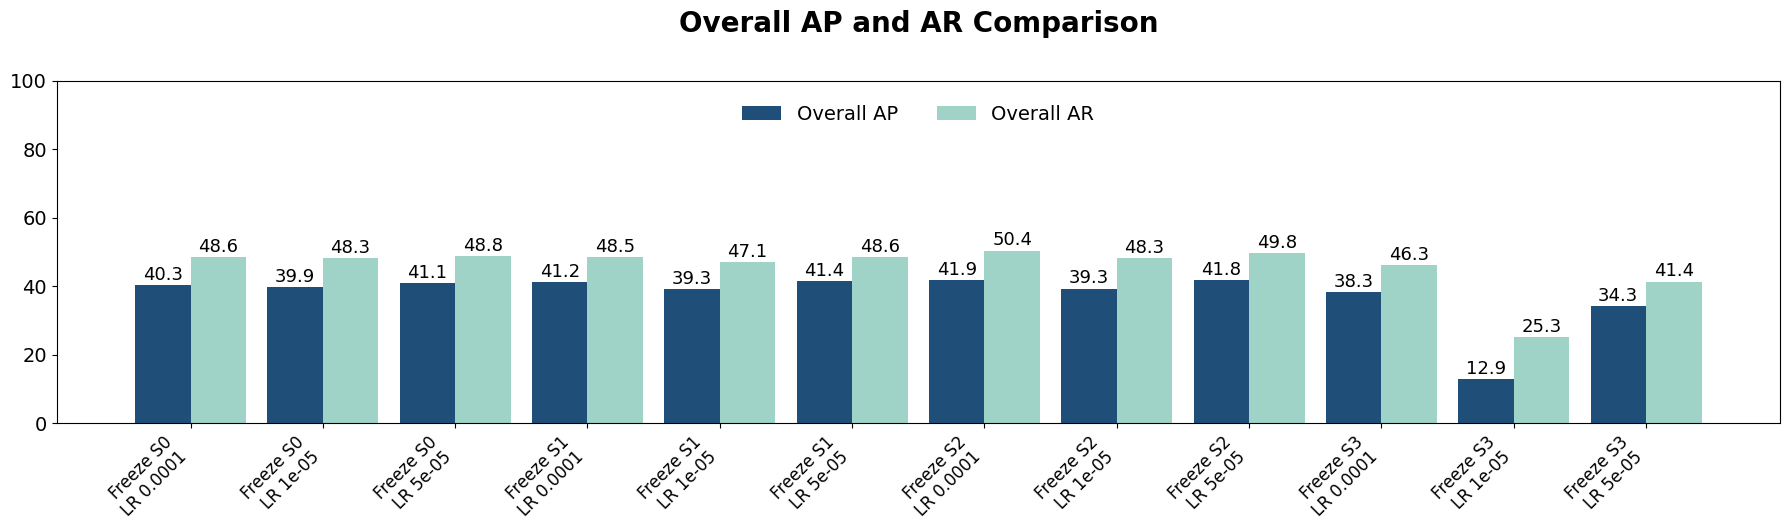

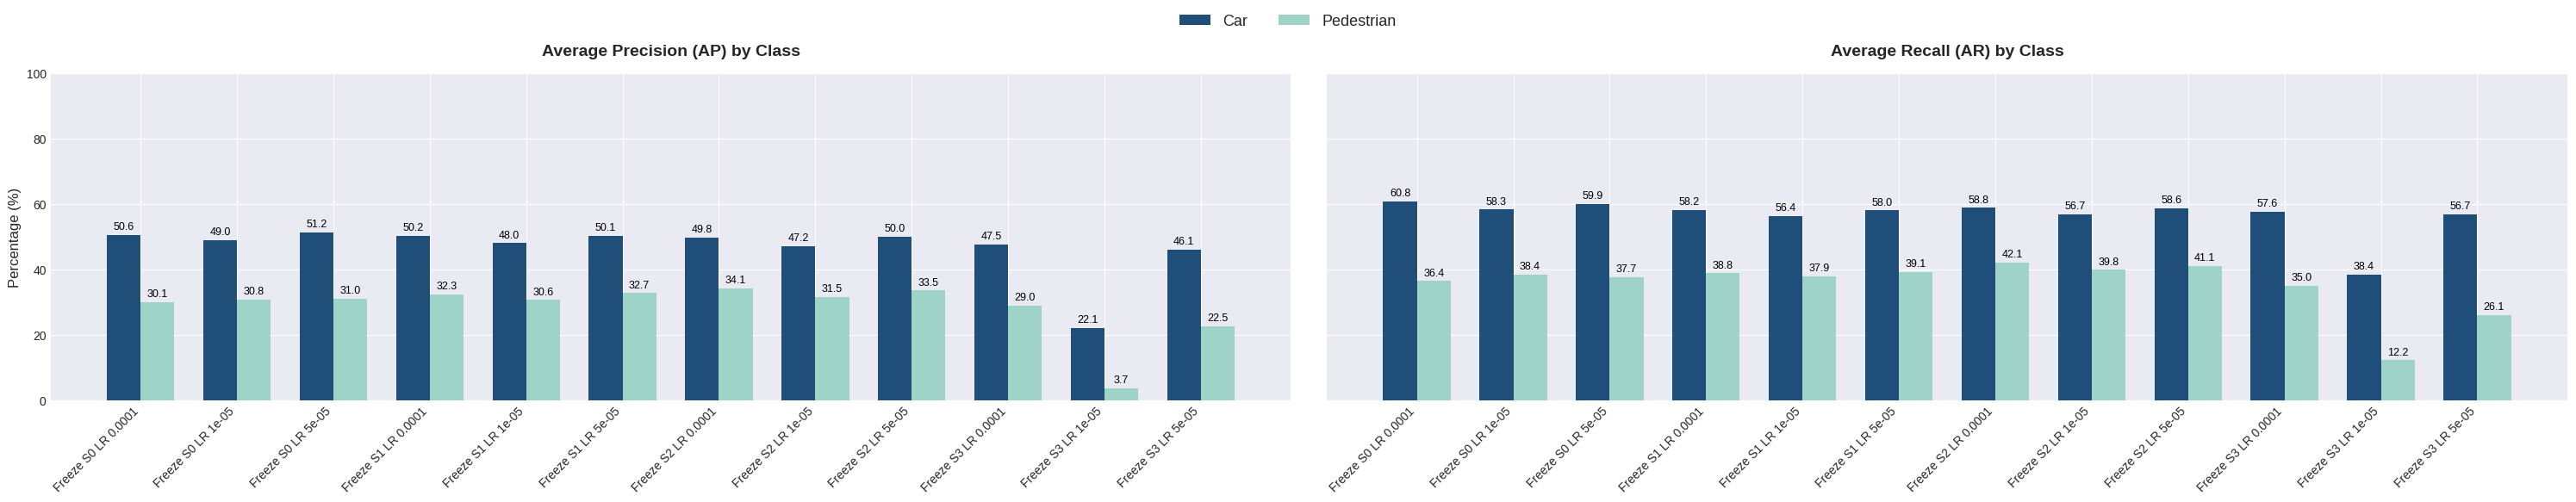

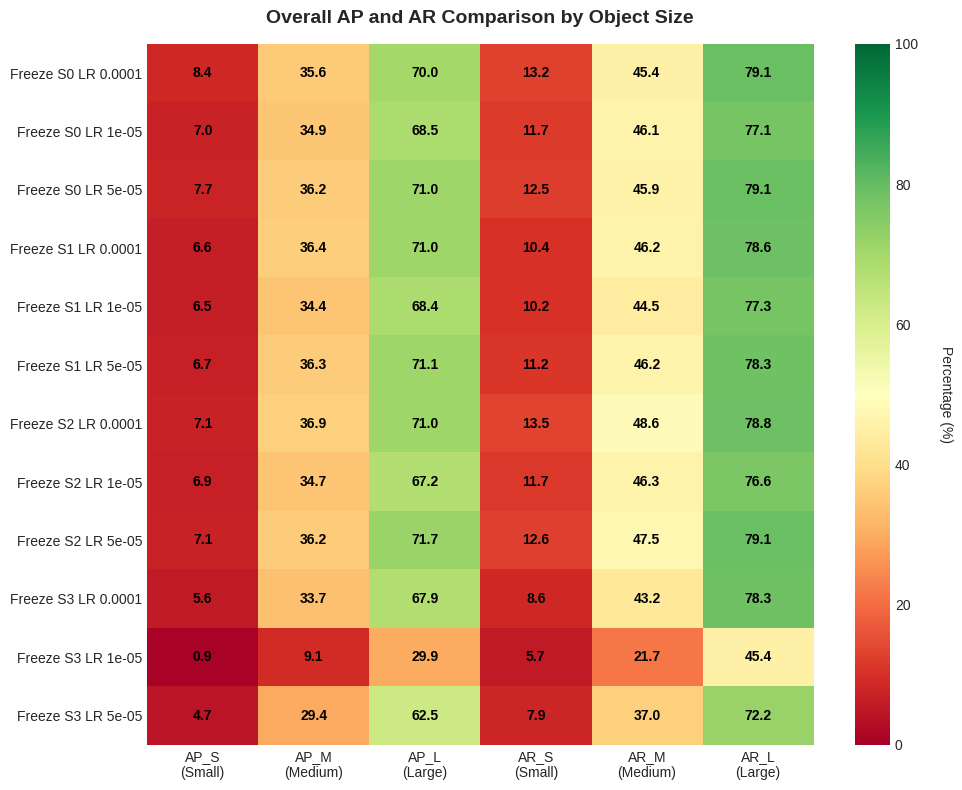

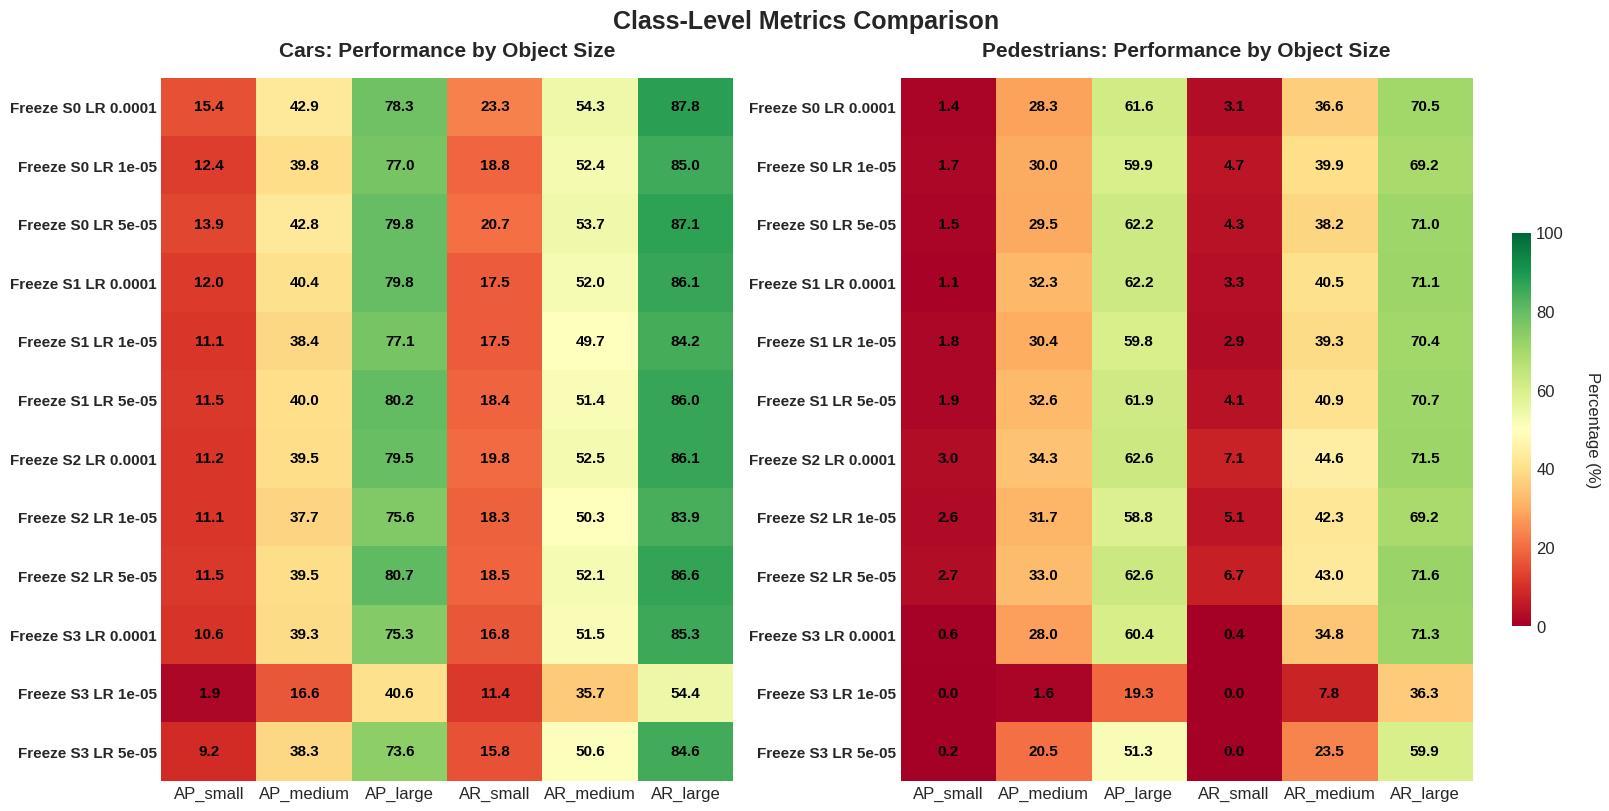

In [3]:
# Load data for the Freeze sweep
results_dir = "../../results/faster_rcnn"
faster_rcnn_freeze_data = load_data(results_dir, prefix="faster_rcnn_Freeze")
faster_rcnn_freeze_data = rename_layer_labels(faster_rcnn_freeze_data)
print(f"Loaded {len(faster_rcnn_freeze_data)} runs for the Freeze sweep.")

plot_overall_bar(faster_rcnn_freeze_data)
plot_per_class_bar(faster_rcnn_freeze_data)
plot_overall_heatmap(faster_rcnn_freeze_data)
plot_per_class_heatmap(faster_rcnn_freeze_data)

### 2. Augmentations Sweep

Loaded 7 runs for the Augmentation sweep.


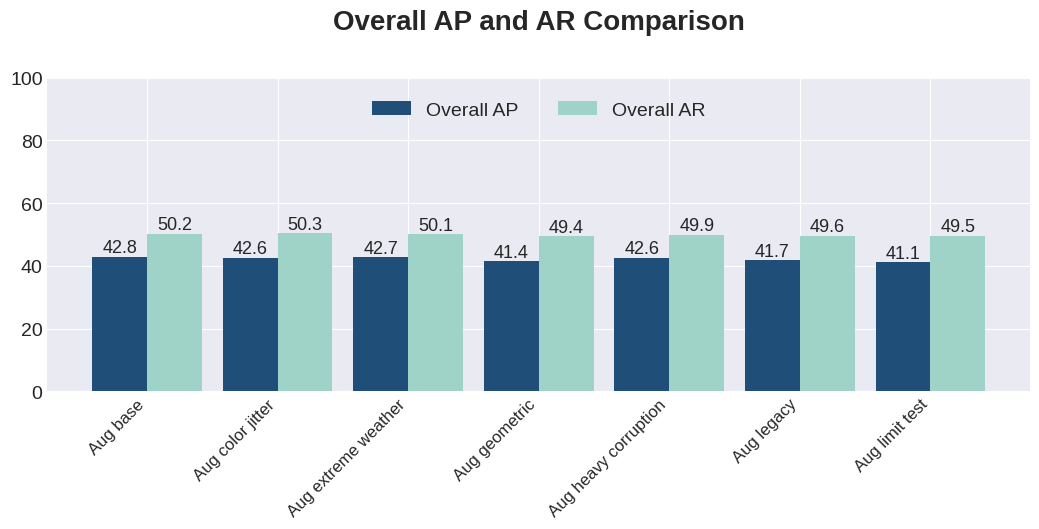

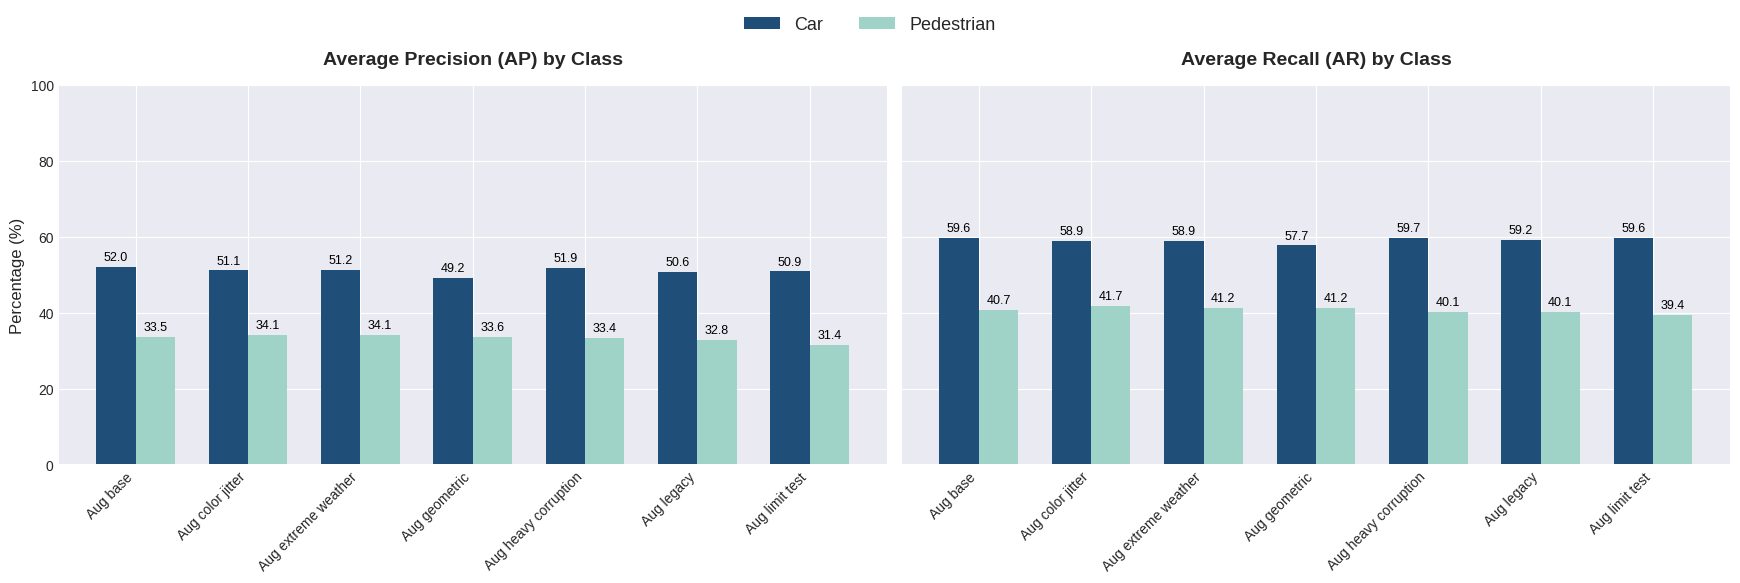

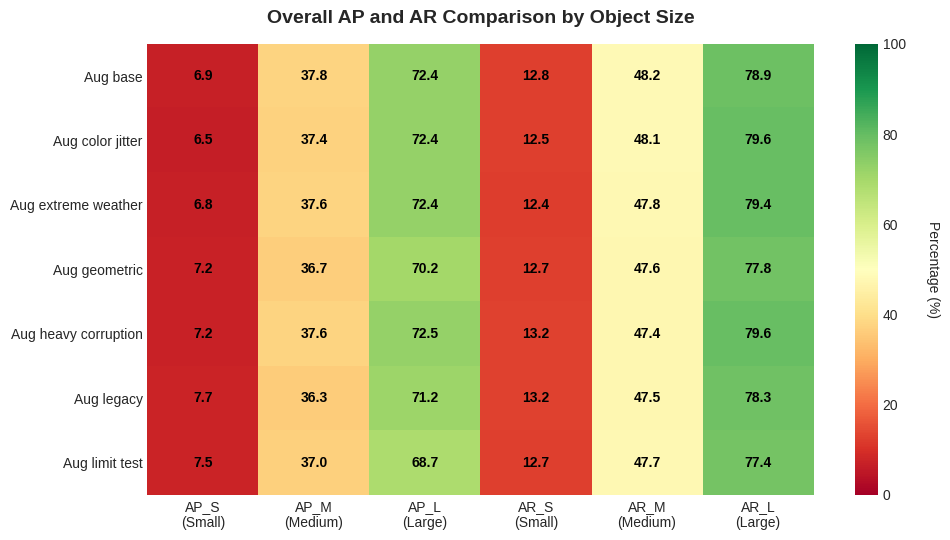

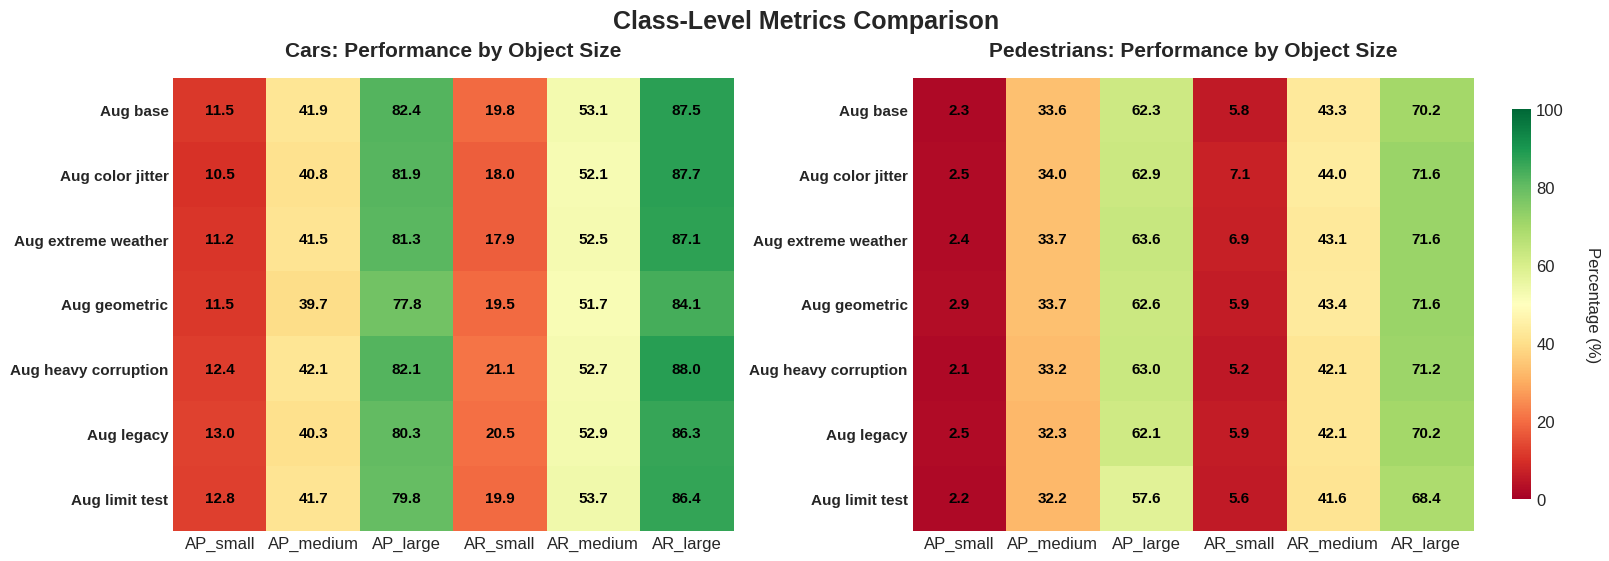

In [4]:
# Load data for the Augmentation sweep
faster_rcnn_aug_data = load_data(results_dir, prefix="faster_rcnn_Aug")
print(f"Loaded {len(faster_rcnn_aug_data)} runs for the Augmentation sweep.")
plot_overall_bar(faster_rcnn_aug_data)
plot_per_class_bar(faster_rcnn_aug_data)
plot_overall_heatmap(faster_rcnn_aug_data)
plot_per_class_heatmap(faster_rcnn_aug_data)

# 3. Evolution

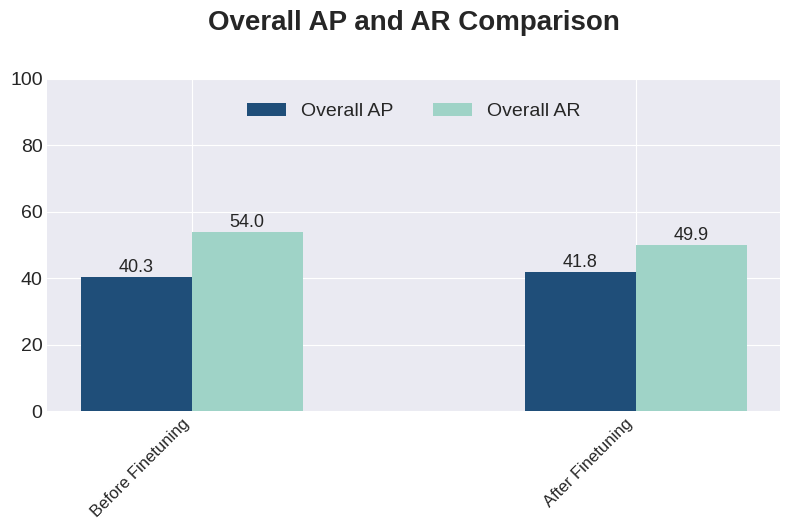

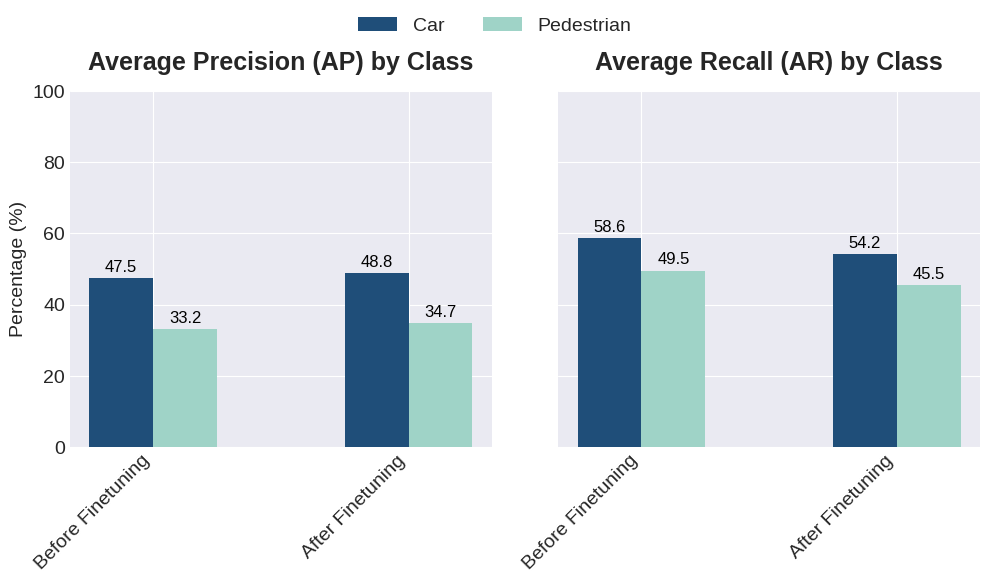

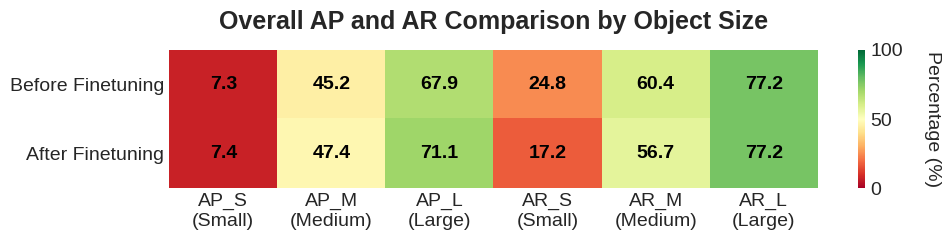

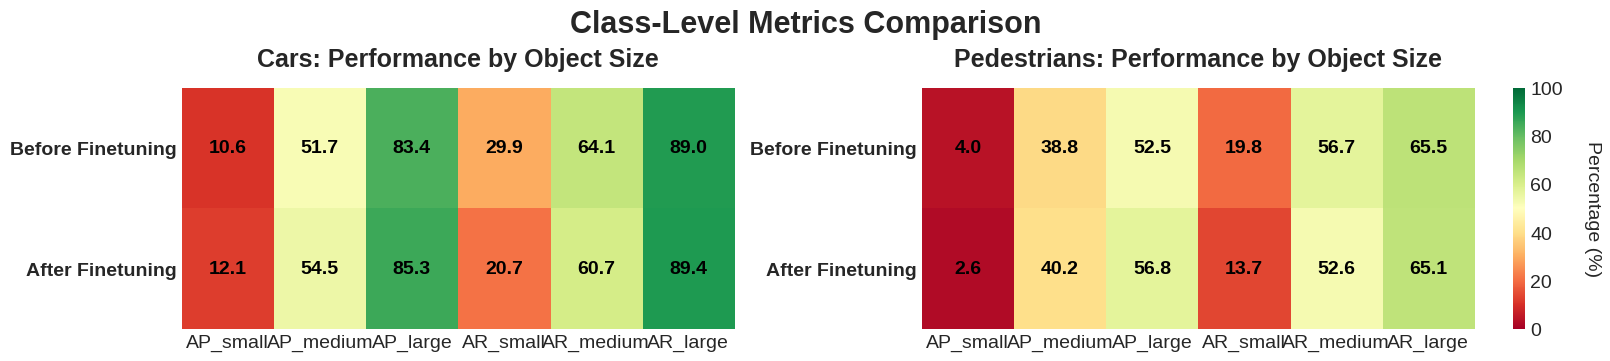

In [5]:
# Paths to the two JSON files
base_metrics_path = Path('/ghome/group01/C5/benet/C5-Team1/Week1/results/faster_rcnn/faster_rcnn_full_final/base_metrics.json')
best_metrics_path = Path('/ghome/group01/C5/benet/C5-Team1/Week1/results/faster_rcnn/faster_rcnn_full_final/best_metrics.json')
# Load the JSON data
with open(base_metrics_path, 'r') as f:
    base_metrics = json.load(f)
    
with open(best_metrics_path, 'r') as f:
    best_metrics = json.load(f)
# Helper function to clean metrics (plot_utils multiplies by 100, so we can't have None values)
def clean_metrics(metrics):
    cleaned = {}
    for k, v in metrics.items():
        if v is None:
            # If AR_max100 or AR_max10 is missing, fall back to AR_max1 just so it plots something
            if 'AR_max' in k:
                base_k = k.replace('100', '1').replace('10', '1')
                cleaned[k] = metrics.get(base_k, 0)
            else:
                cleaned[k] = 0
        else:
            cleaned[k] = v
    return cleaned
# Create the data list expected by plot_utils.py
data = [
    {
        'model': 'Before Finetuning',
        'metrics': clean_metrics(base_metrics),
        'original_dir': 'base_metrics'
    },
    {
        'model': 'After Finetuning',
        'metrics': clean_metrics(best_metrics),
        'original_dir': 'best_metrics'
    }
]
# Now you can easily generate all the plots side-by-side!
plot_overall_bar(data, mode="final")
plot_per_class_bar(data, mode="final")
plot_overall_heatmap(data, mode="final")
plot_per_class_heatmap(data, mode="final")


## DETR

### 1. Freeze Layers Sweep

Loaded 12 runs for the Freeze sweep.


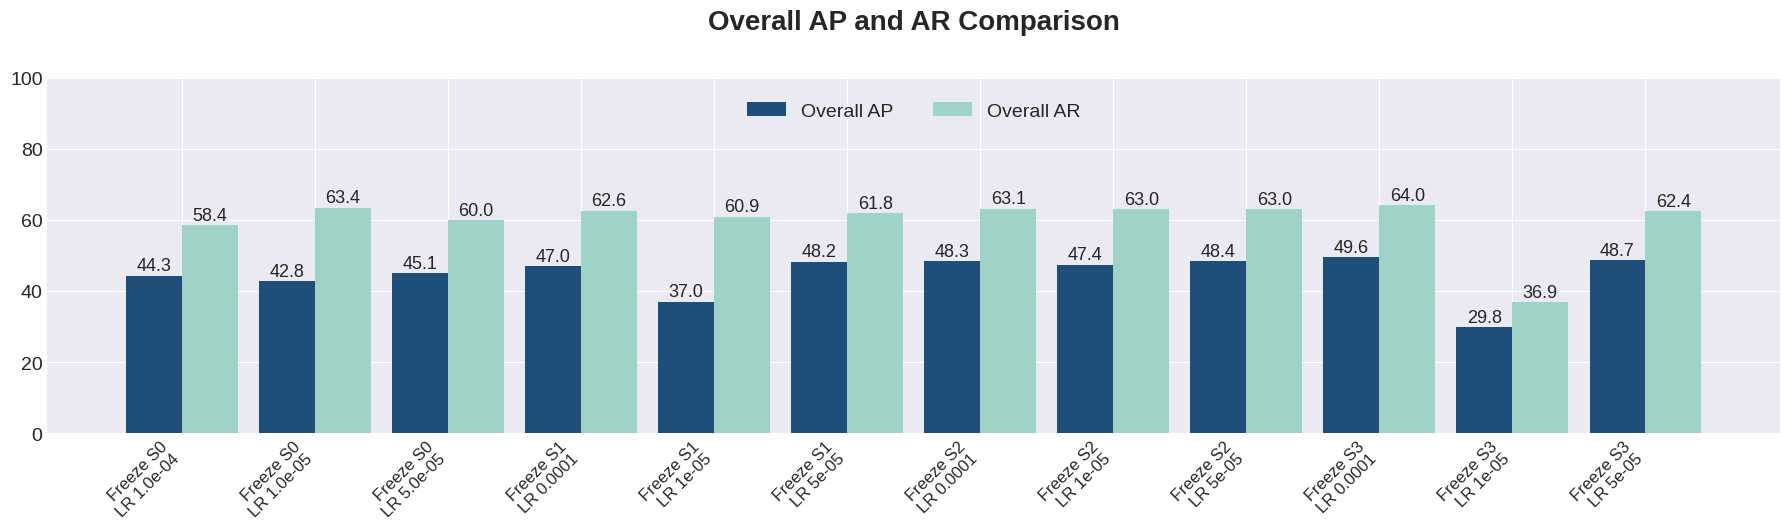

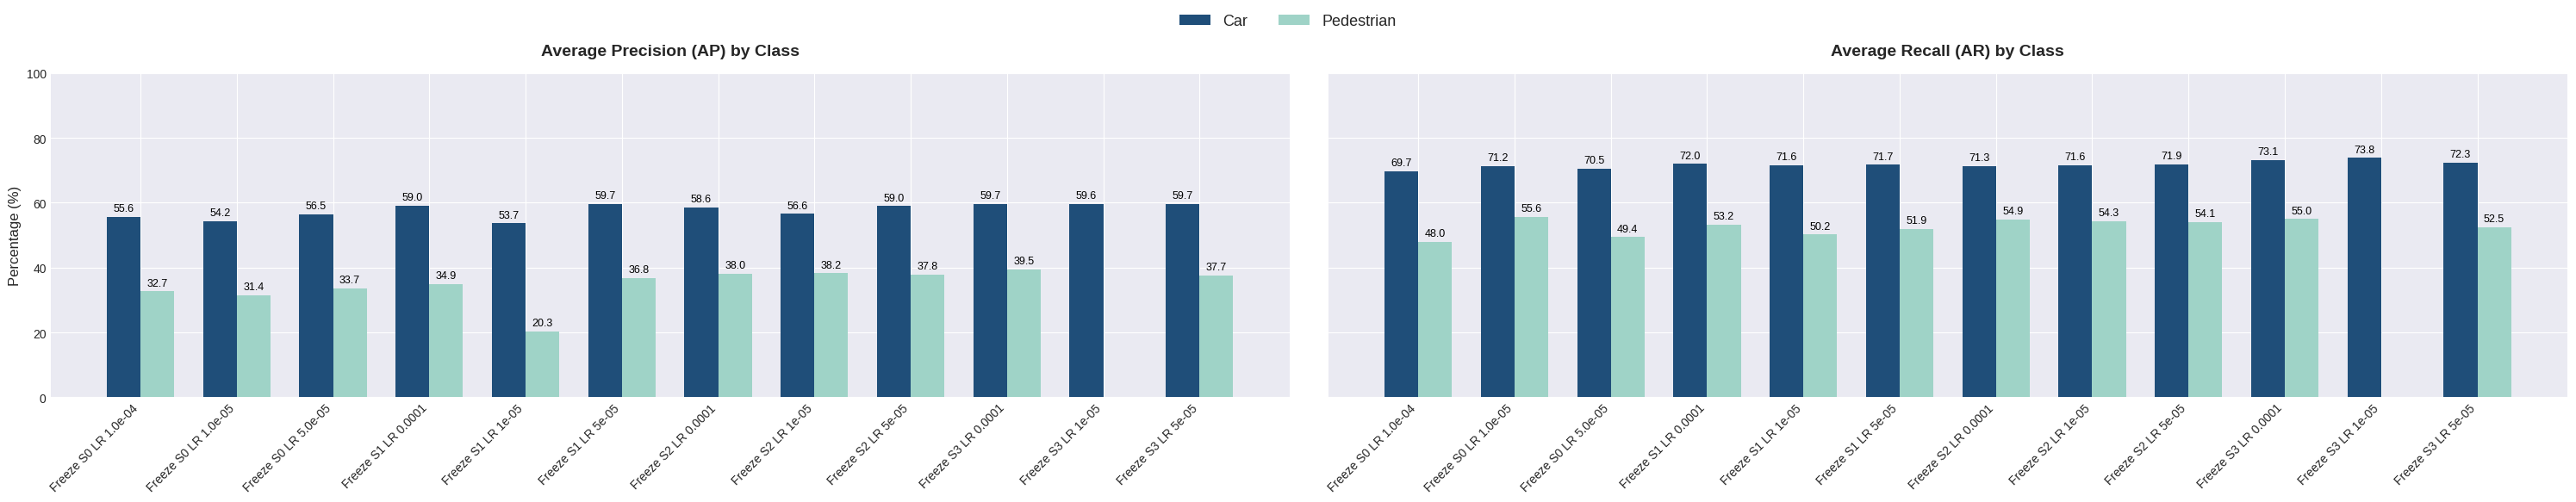

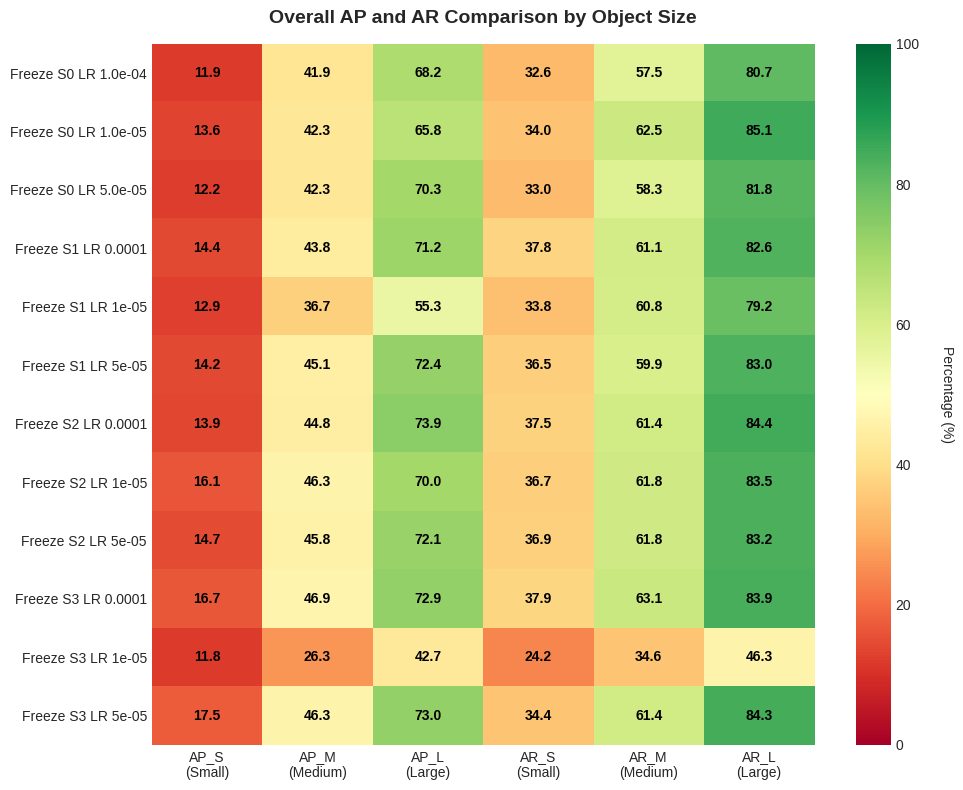

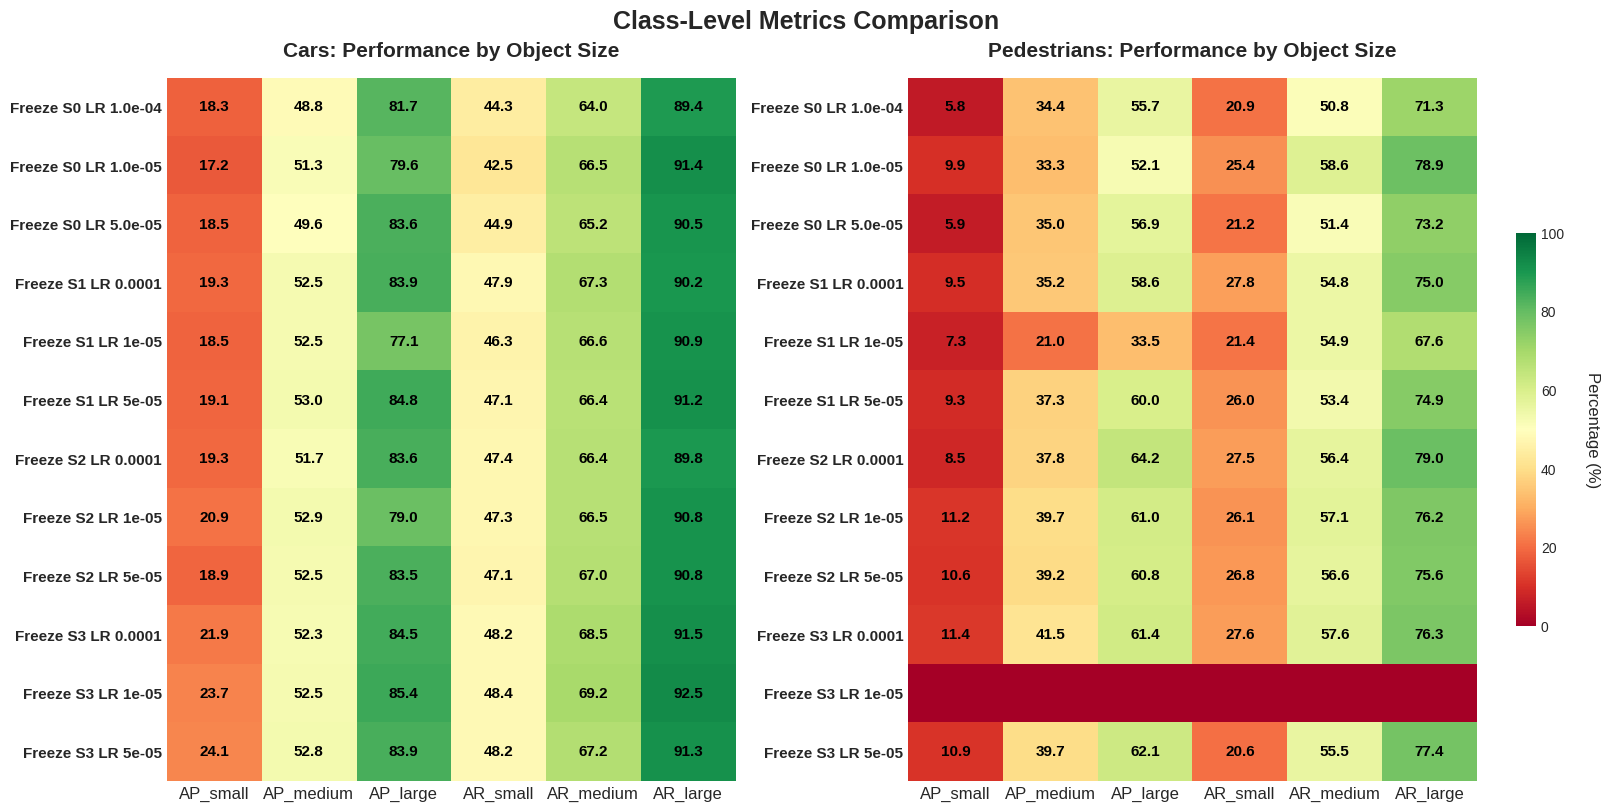

In [6]:
# Load data for the Freeze sweep
results_dir = "../../results/detr"
detr_freeze_data = load_data(results_dir, prefix="detr_Freeze")
print(f"Loaded {len(detr_freeze_data)} runs for the Freeze sweep.")

plot_overall_bar(detr_freeze_data)
plot_per_class_bar(detr_freeze_data)
plot_overall_heatmap(detr_freeze_data)
plot_per_class_heatmap(detr_freeze_data)

### 2. Augmentations Sweep

Analyzing the impact of different augmentation strategies on model performance.

Loaded 7 runs for the Augmentation sweep.


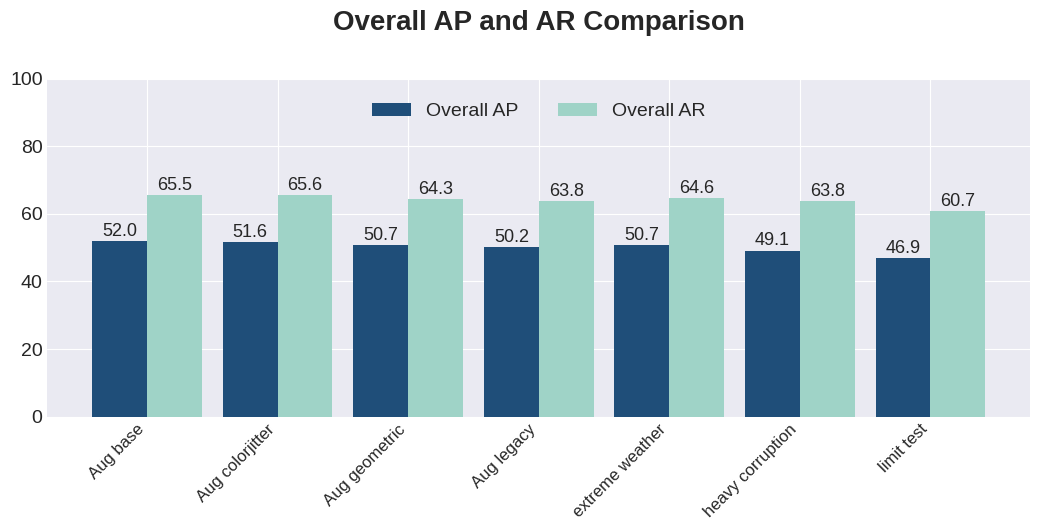

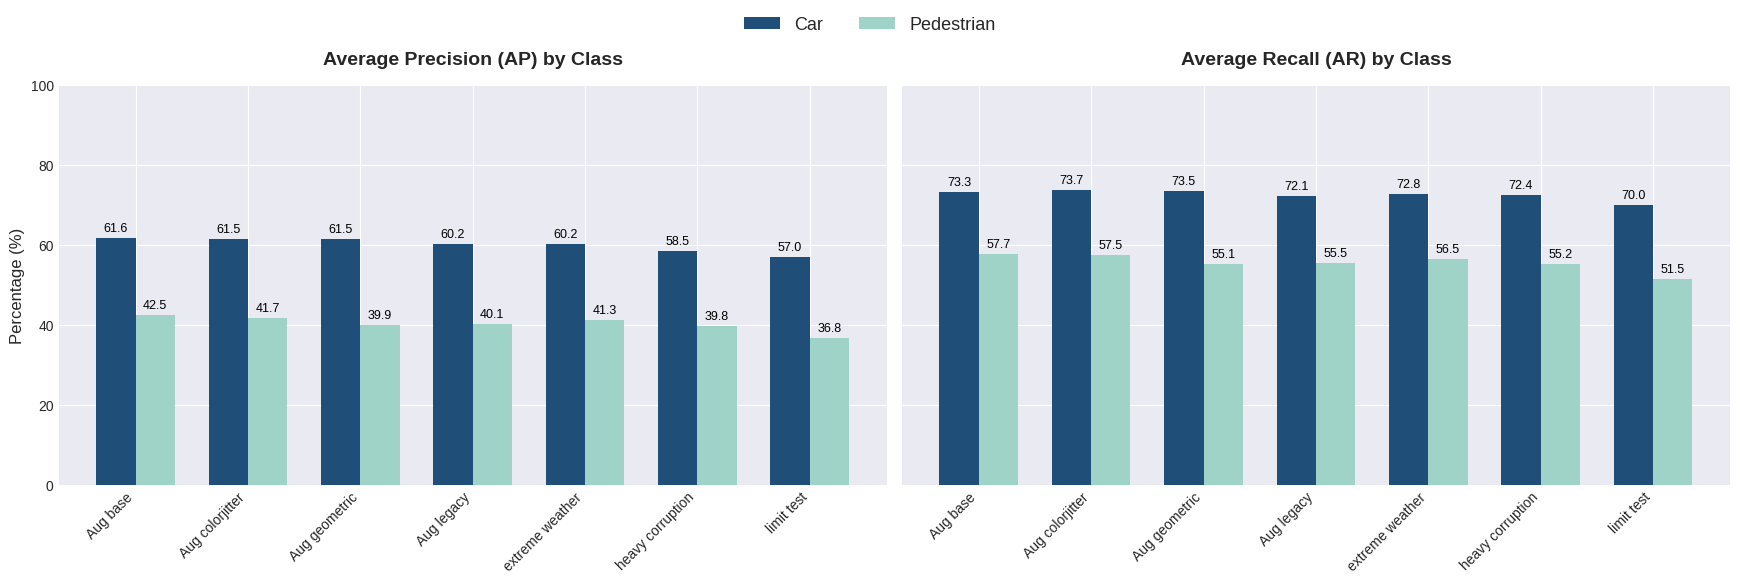

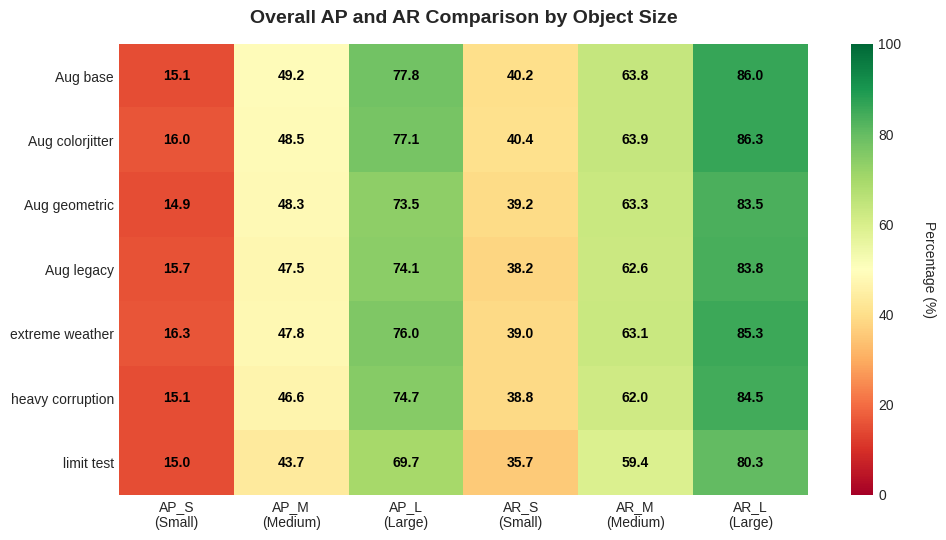

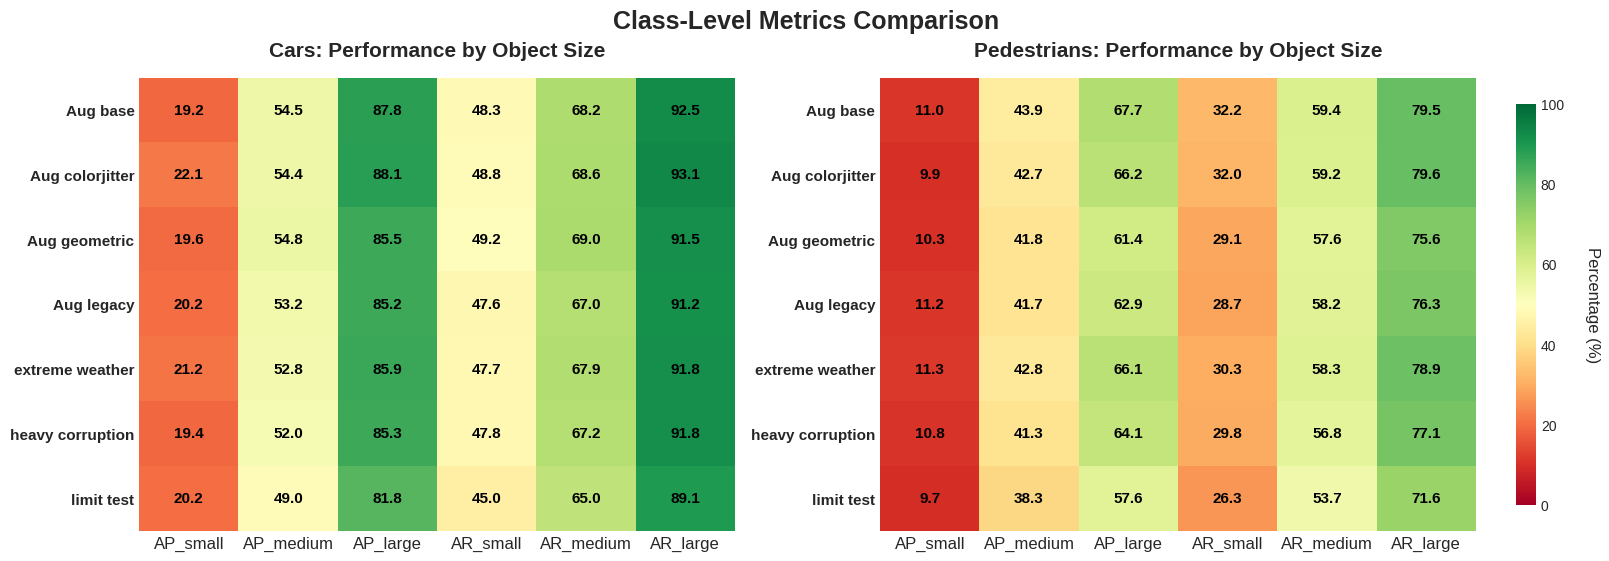

In [29]:
# Load data for the Augmentation sweep
detr_aug_data = load_data(results_dir, prefix="detr_Aug")
print(f"Loaded {len(detr_aug_data)} runs for the Augmentation sweep.")

plot_overall_bar(detr_aug_data)
plot_per_class_bar(detr_aug_data)
plot_overall_heatmap(detr_aug_data)
plot_per_class_heatmap(detr_aug_data)

### 3. Evolution

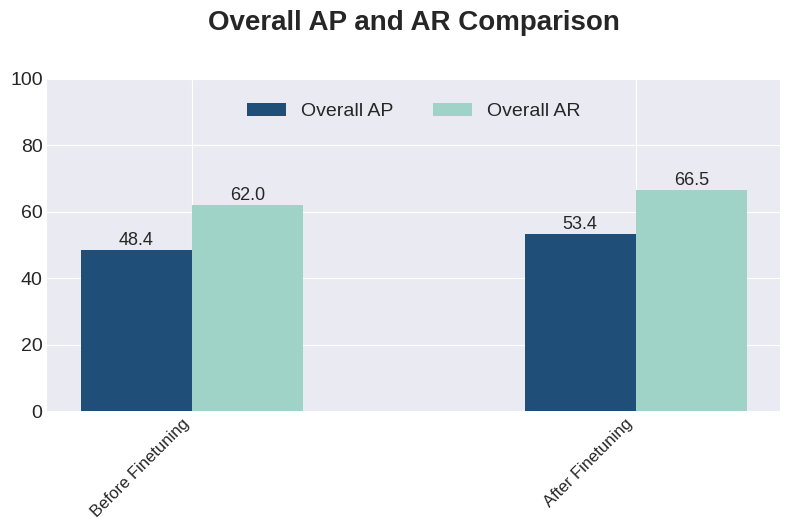

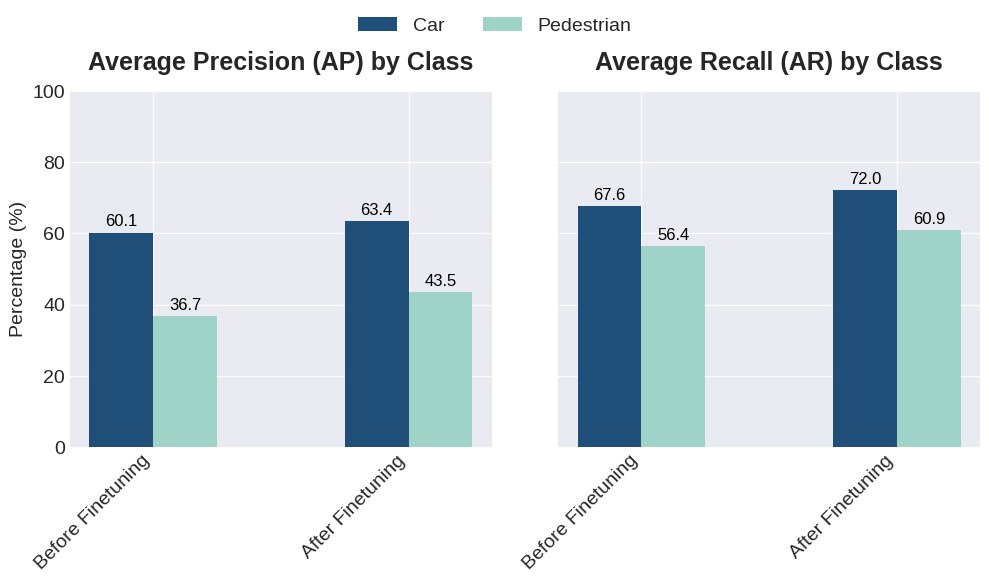

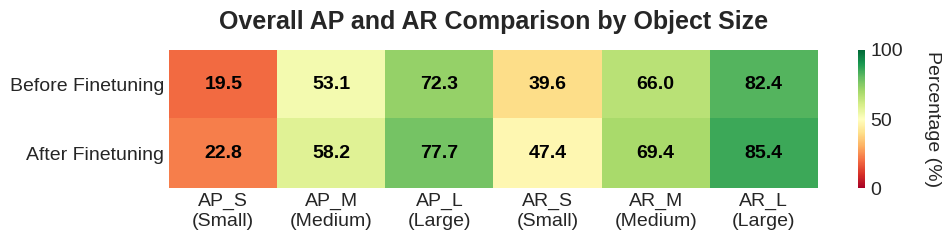

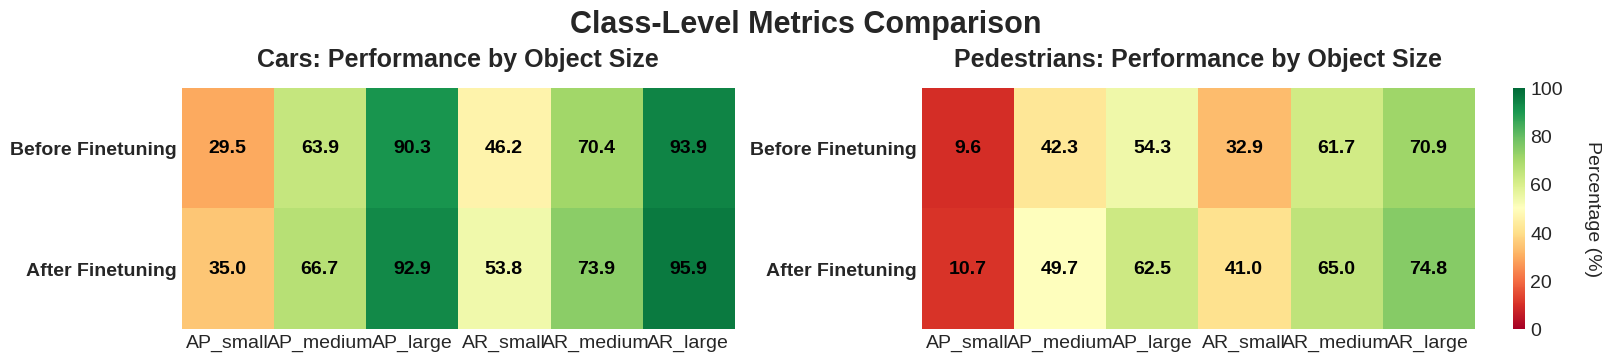

In [7]:
# Paths to the two JSON files
base_metrics_path = Path('/ghome/group01/C5/benet/C5-Team1/Week1/results/detr/detr_full_final/base_metrics.json')
best_metrics_path = Path('/ghome/group01/C5/benet/C5-Team1/Week1/results/detr/detr_full_final/best_metrics.json')
# Load the JSON data
with open(base_metrics_path, 'r') as f:
    base_metrics = json.load(f)
    
with open(best_metrics_path, 'r') as f:
    best_metrics = json.load(f)
# Helper function to clean metrics (plot_utils multiplies by 100, so we can't have None values)
def clean_metrics(metrics):
    cleaned = {}
    for k, v in metrics.items():
        if v is None:
            # If AR_max100 or AR_max10 is missing, fall back to AR_max1 just so it plots something
            if 'AR_max' in k:
                base_k = k.replace('100', '1').replace('10', '1')
                cleaned[k] = metrics.get(base_k, 0)
            else:
                cleaned[k] = 0
        else:
            cleaned[k] = v
    return cleaned
# Create the data list expected by plot_utils.py
data = [
    {
        'model': 'Before Finetuning',
        'metrics': clean_metrics(base_metrics),
        'original_dir': 'base_metrics'
    },
    {
        'model': 'After Finetuning',
        'metrics': clean_metrics(best_metrics),
        'original_dir': 'best_metrics'
    }
]
# Now you can easily generate all the plots side-by-side!
plot_overall_bar(data, mode="final")
plot_per_class_bar(data, mode="final")
plot_overall_heatmap(data, mode="final")
plot_per_class_heatmap(data, mode="final")
